<a href="https://colab.research.google.com/github/Labgod01/XAI-Documentation/blob/main/XAI_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XAI Framework

# 0. Setup

In [1]:
!pip install -q shap lime dice-ml alibi scikit-learn pandas numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 10.1 MB/s eta 0:00:00


In [2]:
import dice_ml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from alibi.explainers import ALE, AnchorTabular
from lime.lime_tabular import LimeTabularExplainer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. Unified User Payload

Model persistence was implemented using Joblib in accordance with the Scikit-learn User Guide (Chapter 9: Model persistence), ensuring efficient serialization and fast memory-mapped loading of large NumPy-based tabular estimators.



## 1.1 Runtime Configuration

**Choose Pipeline Mode.**

In [3]:
import joblib
import pandas as pd
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Global Default Configuration
scoring_metric = None               # Fallback to model's default metric
immutable_features = []             # Default: no locked features for DiCE
class_names = None                  # Default: automatic class inference
query_index = 0                     # Default: explain the 1st instance (iloc[[0]])
features_to_plot = None             # Default: auto-select top features for PDP/ICE
random_state = 42                   # Default seed for reproducibility
active_target = None                # Default: auto-resolved if target_col is a single string
feature_metadata = {}               # e.g., {'feature_name': {'description': '...', 'unit': '...'}}
categorical_features_override = None # If None, automatically detected via dtypes

# Choose pipeline mode:
# - "custom"              : Load your own dataset (.csv) and pre-trained model (.joblib)
# - "demo_classification" : End-to-end classification demo using Breast Cancer dataset
# - "demo_regression"     : End-to-end regression demo using California Housing dataset
PIPELINE_MODE = "demo_classification"  # Options: "custom" | "demo_classification" | "demo_regression"

**Fill in your configuration below. Once configured, you can run all subsequent cells.**


In [4]:
if PIPELINE_MODE == "custom":
    # --- OPTION A: Load user files ---
    DATA_PATH = "data/my_dataset.csv"
    MODEL_PATH = "models/my_model.joblib"

    df = pd.read_csv(DATA_PATH)
    model = joblib.load(MODEL_PATH)

    task_type = "my_task_type"         # Set manually: "classification" or "regression"

    # For single-target:
    target_col = "my_target_column"    # Set manually: Column name for target
    active_target = None               # Not required, target_col is automatically selected

    # --- Or for multi-target (uncomment and edit if needed): ---
    # target_cols = ["y1", "y2"]
    # active_target = "y1"             # Target explained at this run

    # --- User optional overrides (uncomment and edit if needed): ---
    # scoring_metric = None               # e.g., 'roc_auc', 'f1', 'r2', or None for default
    # immutable_features = []             # Features locked against modification for DiCE
    # class_names = None                  # e.g., ['Class A', 'Class B'] for classifier plots
    # query_index = 0                     # Index of the sample row to explain locally
    # features_to_plot = None             # e.g., ['col1', 'col2'] for multi-feature PDP / ICE
    # random_state = 42                   # Seed for reproducible perturbations
    # # Other optional feature metadata:
    # feature_metadata = {
    #     "Age": {"description": "Customer age", "unit": "years"},
    #     "Income": {"description": "Annual gross income", "unit": "k€"}
    # }
    # categorical_features_override = ["Department_ID"]  # e.g., numeric IDs that are actually categorical

elif PIPELINE_MODE == "demo_classification":
    # --- OPTION B1: Demo Classification Workflow ---
    task_type = "classification"
    raw_data = load_breast_cancer(as_frame=True)
    df = raw_data.frame.copy()
    target_col = "target"
    scoring_metric = "accuracy"
    immutable_features = []
    class_names = list(raw_data.target_names)  # ['malignant', 'benign']

    # Train demo classifier
    features_temp = [c for c in df.columns if c != target_col]
    estimator = RandomForestClassifier(n_estimators=30, max_depth=5, random_state=random_state)
    estimator.fit(df[features_temp], df[target_col])
    model = estimator

elif PIPELINE_MODE == "demo_regression":
    # --- OPTION B2: Demo Regression Workflow ---
    task_type = "regression"
    raw_data = fetch_california_housing(as_frame=True)
    df = raw_data.frame.copy()
    target_col = "MedHouseVal"
    scoring_metric = "r2"
    immutable_features = ["Latitude", "Longitude"]  # Locked spatial features for DiCE

    # Train demo regressor
    features_temp = [c for c in df.columns if c != target_col]
    estimator = RandomForestRegressor(n_estimators=30, max_depth=5, random_state=random_state)
    estimator.fit(df[features_temp], df[target_col])
    model = estimator

else:
    raise ValueError(
        f"Invalid PIPELINE_MODE: '{PIPELINE_MODE}'. "
        f"Choose among 'custom', 'demo_classification', or 'demo_regression'."
    )

## 1.3 Dynamic Metadata Extraction

In [5]:
# Isolate predictor feature names
targets = [target_col] if isinstance(target_col, str) else target_col
features_list = [col for col in df.columns if col not in targets]

# Categorical features: Use user override if provided, else detect dynamically
if categorical_features_override is not None:
    categorical_features = categorical_features_override
else:
    categorical_features = df[features_list].select_dtypes(include=['object', 'category']).columns.tolist()

# Numerical features are simply all other features
numerical_features = [col for col in features_list if col not in categorical_features]

# Select first predictor as default for 1D ALE / PDP
default_target_feature = features_list[0]

# If target_col = list, active_target is used
if isinstance(target_col, list):
    resolved_active_target = active_target if active_target is not None else target_col[0]
else:
    resolved_active_target = target_col

## 1.4 Unified User Input Payload

In [6]:
unified_payload = {
    # Trained model object
    "model": model,

    # Reference feature matrix (2D DataFrame without target column)
    "reference_dataset": df[features_list],

    # Ground truth target series for model evaluation and PFI
    "target": df[resolved_active_target],

    # Target instance x to explain locally (2D DataFrame of shape (1, n_features))
    "query_instance": df[features_list].iloc[[query_index]],

    # Execution scope filter: 'local', 'global', or 'both'
    "scope": "both",

    # Metadata dictionary for downstream XAI adapters
    "metadata": {
        "task_type": task_type,
        "target_col": target_col,                     # string or list
        "active_target": resolved_active_target,      # Target explained at this run
        "categorical_features": categorical_features,
        "immutable_features": immutable_features,
        "target_feature": default_target_feature,
        "scoring_metric": scoring_metric,

        # Advanced / Optional Metadata Overrides
        "class_names": class_names,
        "query_index": query_index,
        "features_to_plot": features_to_plot,
        "random_state": random_state,
        "numerical_features": numerical_features,      # Addition for instant use by DiCE / PDP
        "feature_metadata": feature_metadata           # Units, descriptions etc.
    }
}

print(f"[✓] Pipeline ready in mode: '{PIPELINE_MODE}' ({task_type})")
print(f"    - Model Estimator: {type(model).__name__}")
print(f"    - Target Column: '{target_col}'")
print(f"    - Number of Features: {len(features_list)}")
print(f"    - Query Instance Index: {query_index}")
print(f"    - Scoring Metric: '{scoring_metric}'")

[✓] Pipeline ready in mode: 'demo_classification' (classification)
    - Model Estimator: RandomForestClassifier
    - Target Column: 'target'
    - Number of Features: 30
    - Query Instance Index: 0
    - Scoring Metric: 'accuracy'


# 2. Framework Internal Adapter & Transformer Layer

## 2.1 Data Extraction

In [7]:
# Core model and datasets extraction
model = unified_payload["model"]
df_ref = unified_payload["reference_dataset"]  # This is already pure X (features only)
y_labels = unified_payload["target"]           # Ground truth target vector (y)
x_query = unified_payload["query_instance"]    # Single instance for local explanations

# Dynamic metadata extraction
active_target_col = unified_payload["metadata"]["active_target"]
feature_names = list(df_ref.columns)
target_feature = unified_payload["metadata"]["target_feature"]
task_type = unified_payload["metadata"]["task_type"]

## 2.2 Data Transformations

In [8]:
# Convert reference feature set to a 2D NumPy array (for LIME, Anchors, ALE, PDP and ICE training data)
X_np = df_ref.to_numpy()

# Flatten query instance to a 1D NumPy array (required by LIME explain_instance and Anchors)
x_1d = x_query.to_numpy().flatten()

# Reshape query instance to a 2D NumPy array with shape (1, n_features) (used by SHAP)
x_2d = x_query.to_numpy().reshape(1, -1)

# Ensure query instance is a single-row 2D DataFrame for DiCE
x_dice_df = (
    x_query.to_frame().T
    if isinstance(x_query, pd.Series)
    else x_query.iloc[[0]]
)

# PyTorch Tensor conversion for Integrated Gradients (Captum)
try:
    import torch
    x_tensor = torch.tensor(x_query.to_numpy(), dtype=torch.float32)
    x_tensor_baseline = torch.zeros_like(x_tensor)
except ImportError:
    x_tensor = None
    x_tensor_baseline = None


# 3. XAI Methods Explanations

## 3.1 LIME Explanation


--------------- LIMΕ - Raw Values: ---------------
{'target': 'target', 'prediction': '0', 'rules': {'worst area > 1084.00': -0.1350258864484521, 'worst concave points > 0.16': -0.11102945806871084, 'worst perimeter > 125.40': -0.10084016554426155, 'worst radius > 18.79': -0.08781898195310012, 'mean concave points > 0.07': -0.0687201089774097}}

----------------- LIMΕ - Plots: -----------------


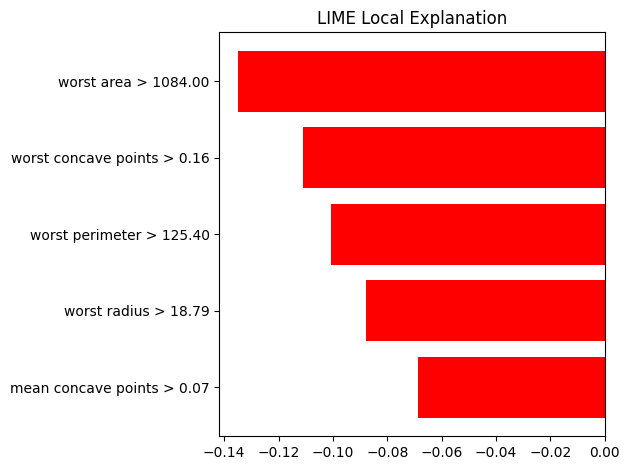

In [30]:
# Iterate dynamically over each target
all_lime_explanations = {}
for current_target in targets:

    # Update unified payload for the active target
    unified_payload["target"] = df[current_target]
    unified_payload["metadata"]["active_target"] = current_target

    if unified_payload["scope"] in ["local", "both"]:

        # Determine prediction function and mode dynamically based on task type
        if task_type == "classification":
            lime_mode = "classification"
            # Wrapper to retain feature names
            predict_fn = lambda x: model.predict_proba(pd.DataFrame(x, columns=feature_names))
        else:
            lime_mode = "regression"
            # Wrapper to retain feature names
            predict_fn = lambda x: model.predict(pd.DataFrame(x, columns=feature_names))

        # Map categorical column names to integer indices for LimeTabularExplainer
        cat_cols = unified_payload["metadata"]["categorical_features"]
        cat_indices = [feature_names.index(col) for col in cat_cols if col in feature_names]

        # Initialize LIME Tabular Explainer
        lime_explainer = LimeTabularExplainer(
            training_data=X_np,
            feature_names=feature_names,
            categorical_features=cat_indices if len(cat_indices) > 0 else None,
            class_names=unified_payload["metadata"]["class_names"],
            mode=lime_mode,
            random_state=unified_payload["metadata"]["random_state"],
        )
        # Generate Instance Explanation
        exp_lime = lime_explainer.explain_instance(
            data_row=x_1d,
            predict_fn=predict_fn,
            num_features=5
        )

        # 1. Extract Raw Explanation Weights as list
        lime_weights = exp_lime.as_list()

        # Safely extract prediction without feature-name warnings or type errors
        raw_pred = model.predict(pd.DataFrame(x_2d, columns=feature_names))[0]
        predicted_val = float(raw_pred) if isinstance(raw_pred, (int, float)) else str(raw_pred)

        # LLM VALUES OUTPUT?
        # lime_llm_payload = {
        #     "method": "LIME",
        #     "target": current_target,
        #     "predicted_class_or_value": predicted_val,
        #     "feature_contributions": [
        #         {"rule": rule, "weight": float(weight)} for rule, weight in lime_weights
        #     ]
        # }
        # # Store in dictionary
        # all_lime_explanations[current_target] = lime_llm_payload

        print("\n--------------- LIMΕ - Raw Values: ---------------")
        lime_llm_payload = {"target": current_target, "prediction": predicted_val, "rules": dict(exp_lime.as_list())}
        print(lime_llm_payload)

        # 2. Visualize Explanation Output
        print("\n----------------- LIMΕ - Plots: -----------------")
        fig = exp_lime.as_pyplot_figure()
        plt.title("LIME Local Explanation")
        plt.tight_layout()
        plt.show()

        exp_lime.show_in_notebook(
        show_table=True,      # bool (Default: False)
        show_all=False,       # bool (Default: True)
        labels=None,          # Iterable[int] (Default: None)
        predict_proba=(task_type == "classification"),  # Only display probabilities in classification mode
    )

## 3.2.1 TreeSHAP Local Explanation

TreeSHAP values shape: (1, 30, 2)

================= SHAP Local - Target: target =================

--------------- SHAP - Raw Values: ---------------
{'method': 'TreeSHAP', 'target': 'target', 'base_value': 0.3702401874633861, 'prediction': 0.9947785730374303, 'feature_contributions': [{'feature': 'worst concave points', 'shap_value': 0.11090082611637188}, {'feature': 'worst area', 'shap_value': 0.06728280757754408}, {'feature': 'mean concave points', 'shap_value': 0.060152401766614905}, {'feature': 'worst perimeter', 'shap_value': 0.0590885457325226}, {'feature': 'worst radius', 'shap_value': 0.049319265716138254}, {'feature': 'worst texture', 'shap_value': -0.04659336307988516}, {'feature': 'area error', 'shap_value': 0.04502965405133748}, {'feature': 'mean perimeter', 'shap_value': 0.0445794631830457}, {'feature': 'mean radius', 'shap_value': 0.038458578995494444}, {'feature': 'mean concavity', 'shap_value': 0.03831025723859768}, {'feature': 'mean area', 'shap_value': 0.03759861055

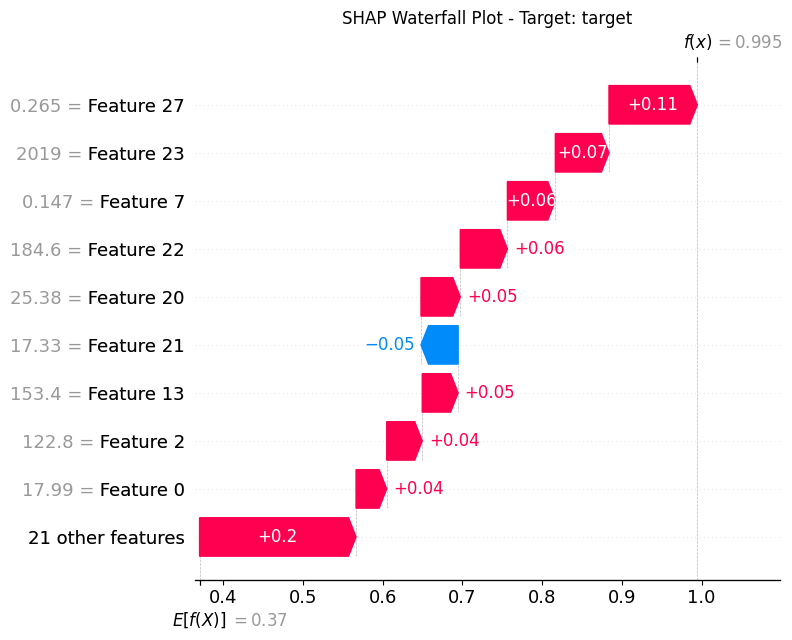

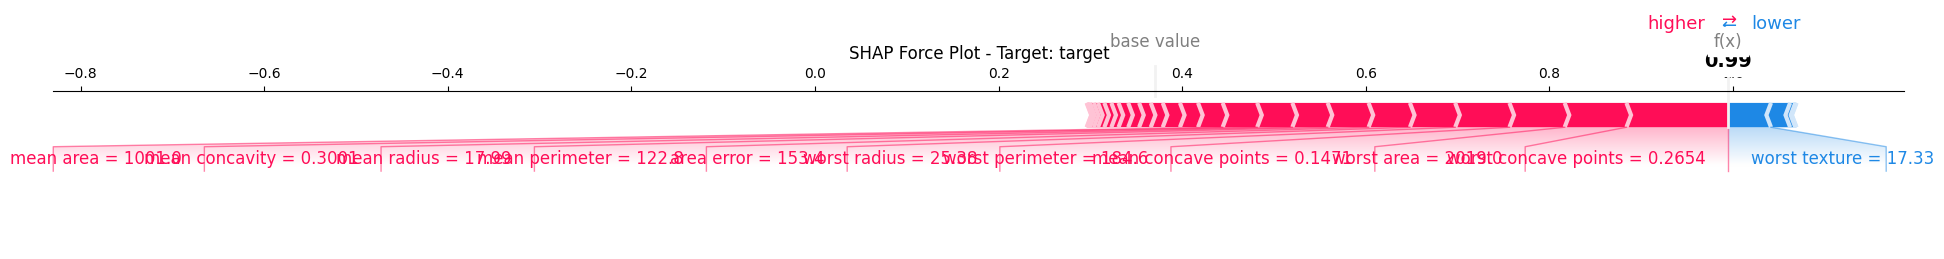

In [35]:
if unified_payload['scope'] in ['local', 'both']:
  # Initialize TreeSHAP Explainer
  tree_explainer = shap.TreeExplainer(model)
  tree_shap_values = tree_explainer(x_2d)
  print(f'TreeSHAP values shape: {tree_shap_values.values.shape}')

  # Container to collect SHAP values across targets for downstream LLM ingestion
  shap_llm_payload = {}

  # Iterate through targets with their integer index
  for target_idx, current_target in enumerate(targets):

    print(f"\n================= TreeSHAP Local - Target: {current_target} =================")

    # ------------------------- Raw Values Extraction -------------------------

    # Slice Explanation object for the single query instance (0) and specific target/class
    if len(tree_shap_values.values.shape) == 3:
      # Multi-class or multi-target shape: (n_samples, n_features, n_classes)
      exp_instance = tree_shap_values[0, :, target_idx]
    else:
      # Single-target regression shape: (n_samples, n_features)
      exp_instance = tree_shap_values[0]

    shap_vals = exp_instance.values
    base_val = float(exp_instance.base_values)

    # Map each feature to its corresponding SHAP value
    feature_contributions = [
        {"feature": feat, "shap_value": float(val)}
        for feat, val in zip(feature_names, shap_vals)
    ]
    # Sort features by absolute contribution impact
    feature_contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

    shap_llm_payload[current_target] = {
        "method": "TreeSHAP",
        "target": current_target,
        "base_value": base_val,
        "prediction": float(base_val + sum(shap_vals)),
        "feature_contributions": feature_contributions
    }
    # ------------------------- TreeSHAP Local Output -------------------------
    print("\n--------------- Local TreeSHAP - Raw Values: ---------------")
    print(shap_llm_payload[current_target])


    print("\n--------------- Global TreeSHAP - Plots ({current_target}): ---------------")

    # Waterfall Plot
    plt.figure()
    shap.plots.waterfall(exp_instance, show=False)
    plt.title(f"SHAP Waterfall Plot - Target: {current_target}")
    plt.tight_layout()
    plt.show()

    # Interactive Force Plot (JavaScript / D3.js rendering)
    shap.initjs()

    # Force Plot (Rendered via Matplotlib for inline display)
    shap.plots.force(
        base_value=exp_instance.base_values,
        shap_values=exp_instance.values,
        features=exp_instance.data,
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP Force Plot - Target: {current_target}")
    plt.tight_layout()
    plt.show()



## 3.2.2 TreeSHAP Global Explanation

Global TreeSHAP values shape: (569, 30, 2)

================= TreeSHAP Global - Target: target =================

--------------- Global SHAP - Raw Values: ---------------
{'method': 'TreeSHAP_Global', 'output_label': 'malignant', 'feature_importance': [{'feature': 'worst concave points', 'mean_abs_shap': 0.06938098148911695}, {'feature': 'mean concave points', 'mean_abs_shap': 0.05692423802446552}, {'feature': 'worst area', 'mean_abs_shap': 0.04571328551046104}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.04355599399778138}, {'feature': 'worst radius', 'mean_abs_shap': 0.03549906160748622}, {'feature': 'mean area', 'mean_abs_shap': 0.034683829150841235}, {'feature': 'mean concavity', 'mean_abs_shap': 0.03396280624643414}, {'feature': 'mean perimeter', 'mean_abs_shap': 0.02961003309593816}, {'feature': 'mean radius', 'mean_abs_shap': 0.027217338341737705}, {'feature': 'area error', 'mean_abs_shap': 0.023452468340910932}, {'feature': 'worst concavity', 'mean_abs_shap': 0.020109256

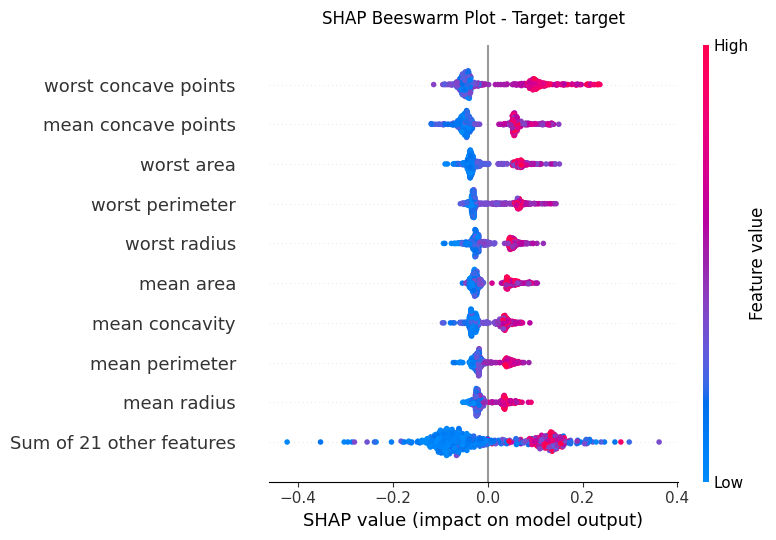

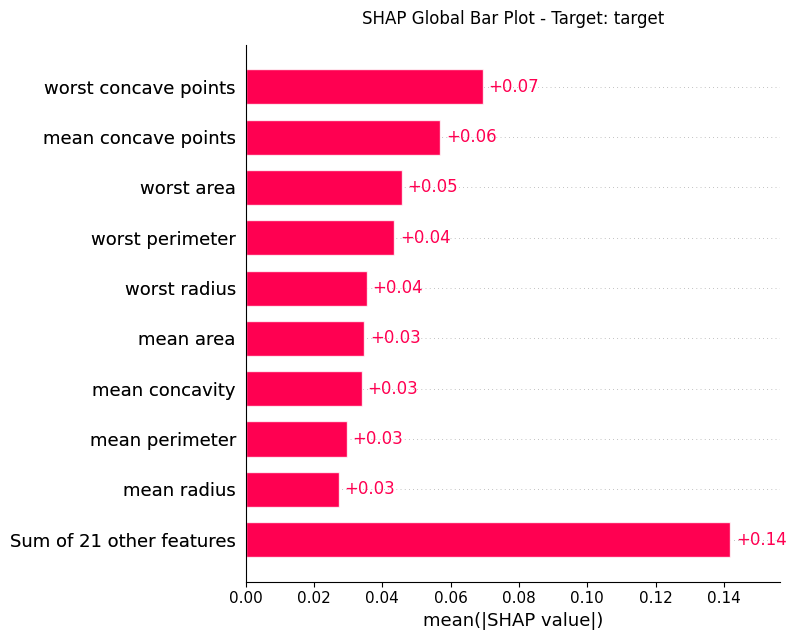

<Figure size 640x480 with 0 Axes>

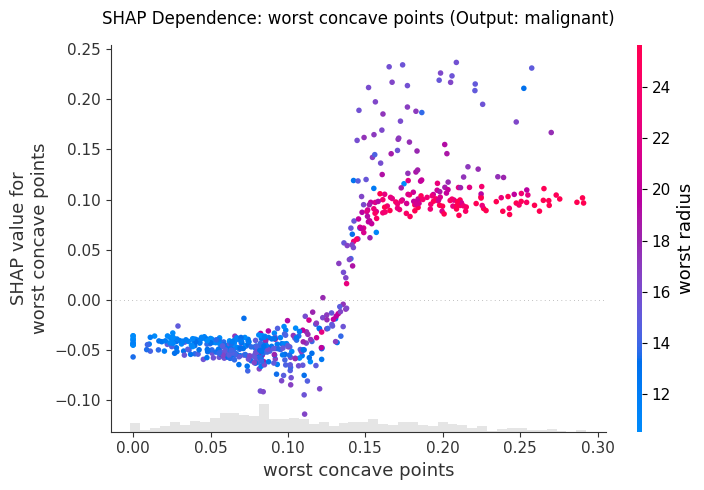


================= TreeSHAP Global - Target: target =================

--------------- Global SHAP - Raw Values: ---------------
{'method': 'TreeSHAP_Global', 'output_label': 'benign', 'feature_importance': [{'feature': 'worst concave points', 'mean_abs_shap': 0.06938098148911698}, {'feature': 'mean concave points', 'mean_abs_shap': 0.05692423802446551}, {'feature': 'worst area', 'mean_abs_shap': 0.045713285510461034}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.04355599399778139}, {'feature': 'worst radius', 'mean_abs_shap': 0.03549906160748621}, {'feature': 'mean area', 'mean_abs_shap': 0.03468382915084123}, {'feature': 'mean concavity', 'mean_abs_shap': 0.033962806246434135}, {'feature': 'mean perimeter', 'mean_abs_shap': 0.02961003309593816}, {'feature': 'mean radius', 'mean_abs_shap': 0.027217338341737715}, {'feature': 'area error', 'mean_abs_shap': 0.023452468340910925}, {'feature': 'worst concavity', 'mean_abs_shap': 0.020109256402578542}, {'feature': 'worst texture', 'mea

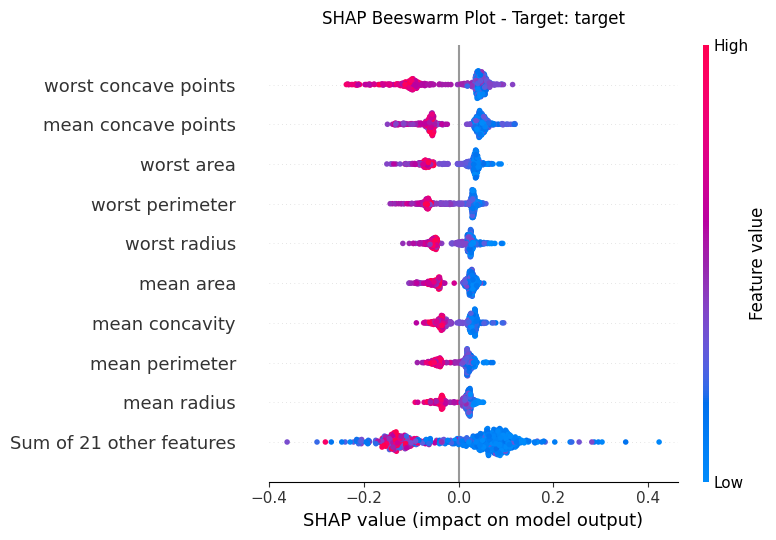

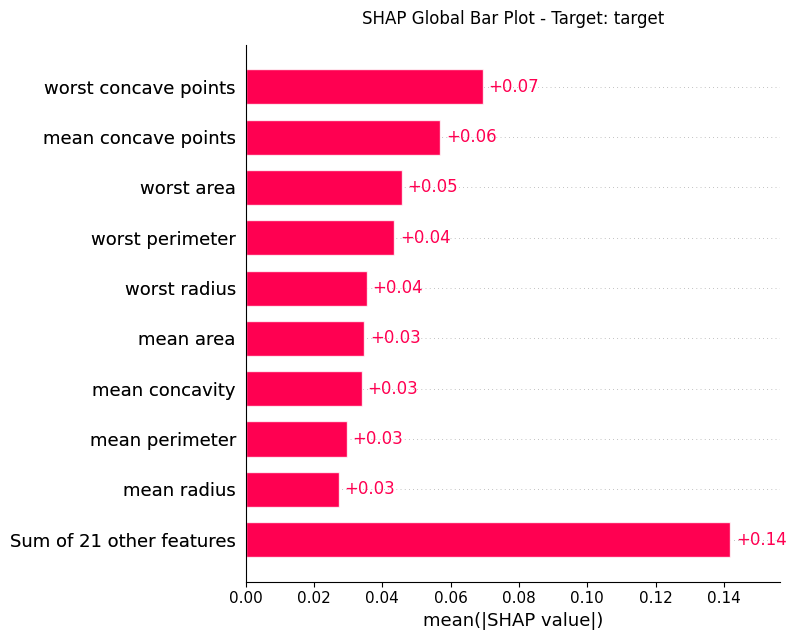

<Figure size 640x480 with 0 Axes>

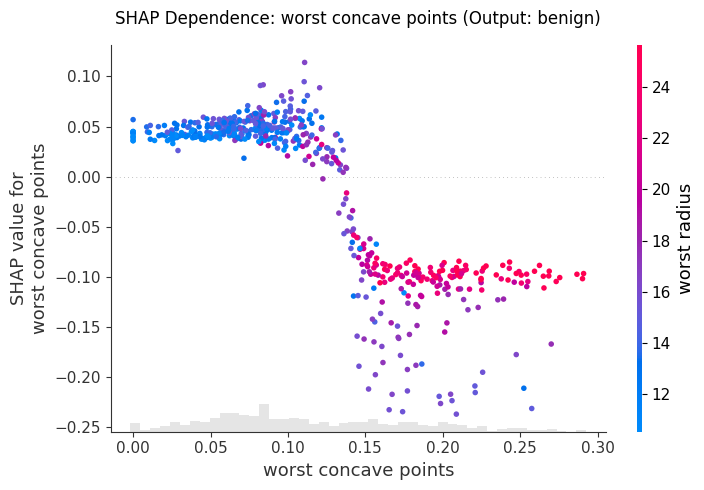

In [38]:
if unified_payload["scope"] in ["global", "both"]:

    # Compute TreeSHAP Explanation across the entire reference dataset (or sample)
    tree_explainer = shap.TreeExplainer(model)
    tree_shap_values_global = tree_explainer(df_ref)
    print(f"Global TreeSHAP values shape: {tree_shap_values_global.values.shape}")

    # Resolve dynamic output labels (classes for classification, targets for regression)
    if task_type == "classification":
        # Extract class names from metadata or fallback to numeric class indices
        output_labels = unified_payload["metadata"].get("class_names")
        if output_labels is None:
            n_classes = tree_shap_values_global.values.shape[-1] if len(tree_shap_values_global.values.shape) == 3 else 2
            output_labels = [f"Class_{i}" for i in range(n_classes)]
    else:
        # Regression: target names (handles both single target string and list of targets)
        output_labels = targets if isinstance(targets, list) else [targets]

    # Container to collect global SHAP feature importances for downstream LLM
    tshap_global_llm_payload = {}

    # Iterate over resolved output labels
    for out_idx, current_label in enumerate(output_labels):

        print(f"\n================= TreeSHAP Global - Target: {current_target} =================")

        # Slice Explanation object safely for current output
        if len(tree_shap_values_global.values.shape) == 3:
            # 3D Array: (n_samples, n_features, n_classes/targets) -> Slice to 2D
            exp_global = tree_shap_values_global[:, :, out_idx]
        else:
            # 2D Array: Single-target regression
            exp_global = tree_shap_values_global

        # ------------------------- TreeSHAP Raw Values Extraction -------------------------

        # TreeSHAP Global Feature Importance extraction for LLM
        mean_abs_shap = np.mean(np.abs(exp_global.values), axis=0)
        global_contributions = [
            {"feature": feat, "mean_abs_shap": float(val)}
            for feat, val in zip(feature_names, mean_abs_shap)
        ]
        global_contributions.sort(key=lambda x: x["mean_abs_shap"], reverse=True)

        tshap_global_llm_payload[str(current_label)] = {
            "method": "TreeSHAP_Global",
            "output_label": str(current_label),
            "feature_importance": global_contributions
        }

        print("\n--------------- Global TreeSHAP - Raw Values: ---------------")
        print(tshap_global_llm_payload[str(current_label)])

        # ------------------------- TreeSHAP Gloabl Output -------------------------
        print(f"\n--------------- Global TreeSHAP - Plots ({current_target}): ---------------")

        # TreeSHAP Beeswarm / Summary Plot
        plt.figure()
        shap.plots.beeswarm(exp_global, show=False)
        plt.title(f"SHAP Beeswarm Plot - Target: {current_target}", pad=15)
        plt.tight_layout()
        plt.show()

        # TreeSHAP Global Feature Importance Bar Plot
        plt.figure()
        shap.plots.bar(exp_global, show=False)
        plt.title(f"SHAP Global Bar Plot - Target: {current_target}", pad=15)
        plt.tight_layout()
        plt.show()

        # TreeSHAP Global Dynamic Dependence Plot (Top Feature)
        top_feature = global_contributions[0]["feature"]
        plt.figure()
        shap.plots.scatter(
            exp_global[:, top_feature],   # Strictly 1D slice
            color=exp_global,             # 2D slice for interaction color
            show=False
        )

        plt.title(f"TreeSHAP Dependence: {top_feature} (Output: {current_label})", pad=15)
        plt.tight_layout()
        plt.show()

## 3.3.1 KernelSHAP Local Explanation

  0%|          | 0/1 [00:00<?, ?it/s]

KernelSHAP values shape: (1, 30, 2)

================= KernelSHAP Local - Output: malignant =================

--------------- Local KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP', 'target': 'malignant', 'base_value': 0.3919133933179485, 'prediction': 0.9947785730374303, 'feature_contributions': [{'feature': 'worst area', 'shap_value': 0.11425644769562346}, {'feature': 'worst concave points', 'shap_value': 0.10217645503116432}, {'feature': 'worst perimeter', 'shap_value': 0.08602268389748742}, {'feature': 'mean concave points', 'shap_value': 0.07756253990959261}, {'feature': 'mean area', 'shap_value': 0.06942016422969333}, {'feature': 'worst radius', 'shap_value': 0.05070549271559594}, {'feature': 'mean radius', 'shap_value': 0.040287112753431}, {'feature': 'mean perimeter', 'shap_value': 0.027357503597802573}, {'feature': 'mean fractal dimension', 'shap_value': 0.02311411500049863}, {'feature': 'compactness error', 'shap_value': 0.011962664888592586}, {'feature': 'me

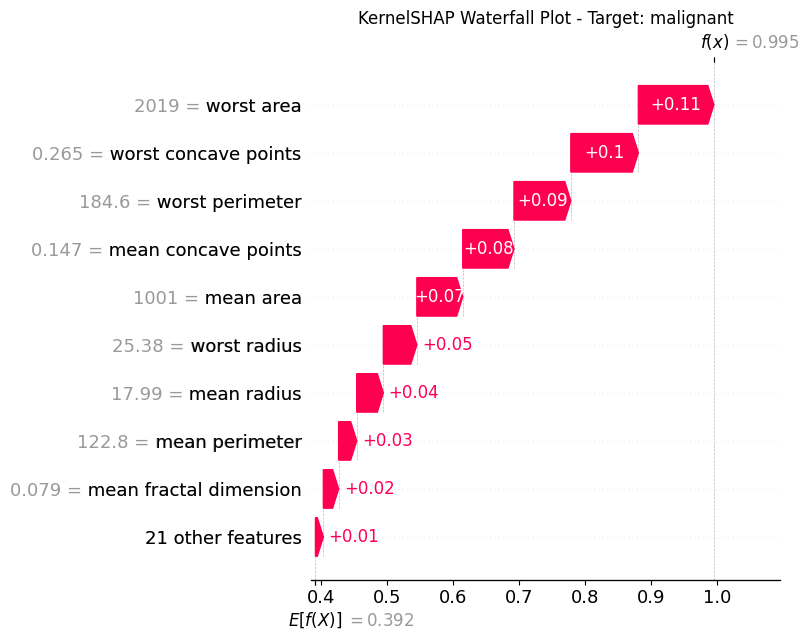

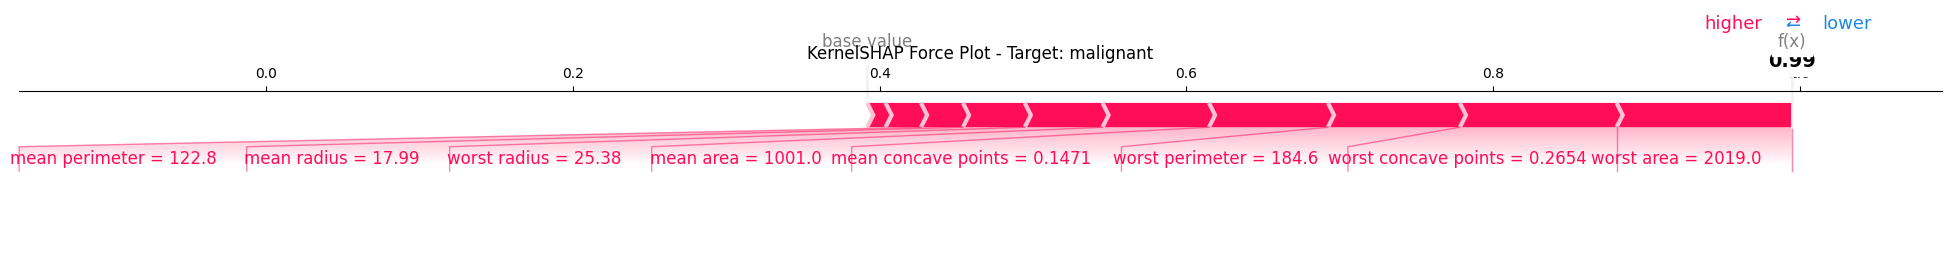


================= KernelSHAP Local - Output: benign =================

--------------- Local KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP', 'target': 'benign', 'base_value': 0.3919133933179485, 'prediction': -0.21095178640153278, 'feature_contributions': [{'feature': 'worst area', 'shap_value': -0.11425644769562332}, {'feature': 'worst concave points', 'shap_value': -0.10217645503116407}, {'feature': 'worst perimeter', 'shap_value': -0.08602268389748742}, {'feature': 'mean concave points', 'shap_value': -0.07756253990959251}, {'feature': 'mean area', 'shap_value': -0.06942016422969317}, {'feature': 'worst radius', 'shap_value': -0.05070549271559597}, {'feature': 'mean radius', 'shap_value': -0.04028711275343089}, {'feature': 'mean perimeter', 'shap_value': -0.027357503597802636}, {'feature': 'mean fractal dimension', 'shap_value': -0.023114115000498956}, {'feature': 'compactness error', 'shap_value': -0.011962664888592428}, {'feature': 'mean texture', 'shap_value': 

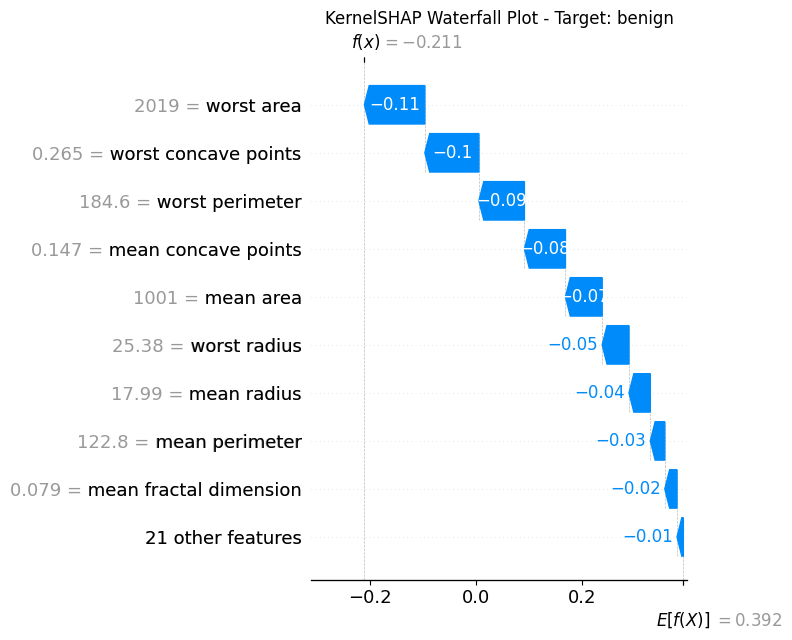

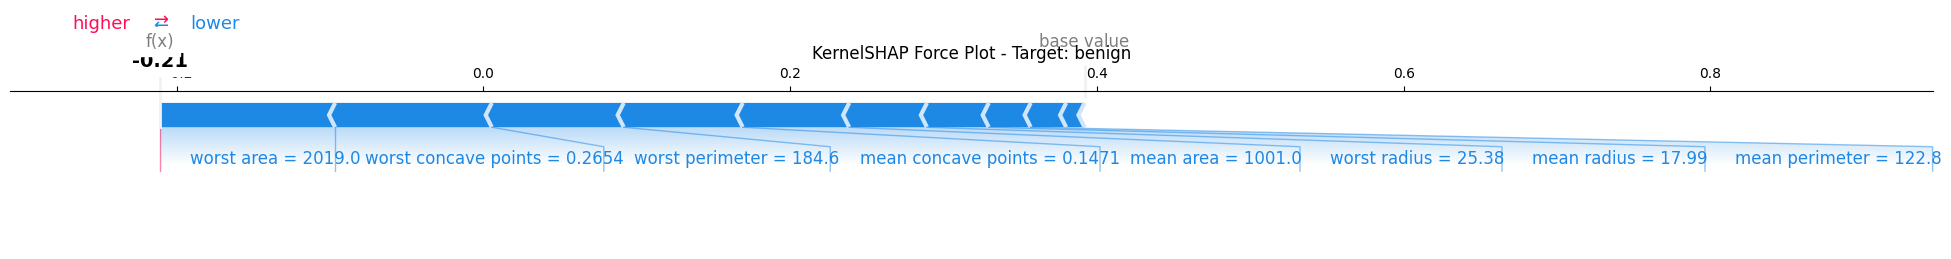

In [40]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

if unified_payload['scope'] in ['local', 'both']:
    # 1. Background data summary (50 samples for speed)
    background_data = shap.sample(df_ref, 50)

    # 2. Select prediction function dynamically
    predict_fn = model.predict_proba if task_type == 'classification' else model.predict

    # 3. Direct KernelExplainer initialization
    # Wrapped with lambda to guarantee DataFrame input with feature names
    kernel_explainer = shap.KernelExplainer(
        lambda x: predict_fn(pd.DataFrame(x, columns=feature_names)),
        background_data
    )

    # Compute raw shap values
    raw_shap_values = kernel_explainer.shap_values(
        pd.DataFrame(x_2d, columns=feature_names),
        nsamples=100
    )

    # 4. Wrap raw values into a native shap.Explanation object
    expected_val = kernel_explainer.expected_value

    # Convert list output (multiclass) to 3D array: (n_instances, n_features, n_classes)
    if isinstance(raw_shap_values, list):
        stacked_values = np.stack(raw_shap_values, axis=-1)
        expected_val = np.array(expected_val)
    else:
        stacked_values = np.array(raw_shap_values)

    kernel_shap_values = shap.Explanation(
        values=stacked_values,
        base_values=expected_val,
        data=x_2d,
        feature_names=feature_names
    )
    print(f'KernelSHAP values shape: {kernel_shap_values.values.shape}')

    # Resolve labels dynamically (classes for classification, targets for regression)
    if task_type == 'classification':
        output_labels = unified_payload['metadata'].get('class_names')
        if output_labels is None:
            n_classes = kernel_shap_values.values.shape[-1] if len(kernel_shap_values.values.shape) == 3 else 2
            output_labels = [f"Class_{i}" for i in range(n_classes)]
    else:
        output_labels = targets if isinstance(targets, list) else [targets]

    # Container to collect SHAP values across targets/classes for LLM ingestion
    kshap_llm_payload = {}

    # Iterate through outputs
    for target_idx, current_target in enumerate(output_labels):

        print(f"\n================= KernelSHAP Local - Output: {current_target} =================")

        # ------------------------- Raw Values Extraction -------------------------
        # Slice Explanation object for the single query instance (0) and specific class/target
        if len(kernel_shap_values.values.shape) == 3:
            exp_instance = kernel_shap_values[0, :, target_idx]
        else:
            exp_instance = kernel_shap_values[0]

        shap_vals = exp_instance.values
        base_val = float(exp_instance.base_values)

        feature_contributions = [
            {"feature": feat, "shap_value": float(val)}
            for feat, val in zip(feature_names, shap_vals)
        ]
        feature_contributions.sort(key=lambda x: abs(x["shap_value"]), reverse=True)

        kshap_llm_payload[str(current_target)] = {
            "method": "KernelSHAP",
            "target": str(current_target),
            "base_value": base_val,
            "prediction": float(base_val + sum(shap_vals)),
            "feature_contributions": feature_contributions
        }

        # ------------------------- KernelSHAP Local Output -------------------------
        print("\n--------------- Local KernelSHAP - Raw Values: ---------------")
        print(kshap_llm_payload[str(current_target)])

        print(f"\n--------------- Local KernelSHAP - Plots ({current_target}): ---------------")

        # KernelSHAP Waterfall Plot
        plt.figure()
        shap.plots.waterfall(exp_instance, show=False)
        plt.title(f"KernelSHAP Waterfall Plot - Target: {current_target}")
        plt.tight_layout()
        plt.show()

        # KernelSHAP Force Plot (Matplotlib version for inline/script export)
        shap.plots.force(
            base_value=exp_instance.base_values,
            shap_values=exp_instance.values,
            features=exp_instance.data,
            feature_names=feature_names,
            matplotlib=True,
            show=False
        )
        plt.title(f"KernelSHAP Force Plot - Target: {current_target}")
        plt.tight_layout()
        plt.show()

## 3.3.2 KernelSHAP Global Explanation

  0%|          | 0/100 [00:00<?, ?it/s]

Global KernelSHAP values shape: (100, 30, 2)

================= KernelSHAP Global - Output: malignant =================

--------------- Global KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP_Global', 'output_label': 'malignant', 'feature_importance': [{'feature': 'worst area', 'mean_abs_shap': 0.0715089452214298}, {'feature': 'mean concave points', 'mean_abs_shap': 0.05787530068098008}, {'feature': 'worst concave points', 'mean_abs_shap': 0.05781438857960512}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.05203573519119395}, {'feature': 'worst radius', 'mean_abs_shap': 0.042090593577492126}, {'feature': 'mean area', 'mean_abs_shap': 0.02897415214394926}, {'feature': 'mean concavity', 'mean_abs_shap': 0.02051273128547139}, {'feature': 'area error', 'mean_abs_shap': 0.016954167769809788}, {'feature': 'worst concavity', 'mean_abs_shap': 0.01661293784309751}, {'feature': 'mean radius', 'mean_abs_shap': 0.014888547128072355}, {'feature': 'worst texture', 'mean_abs_shap'

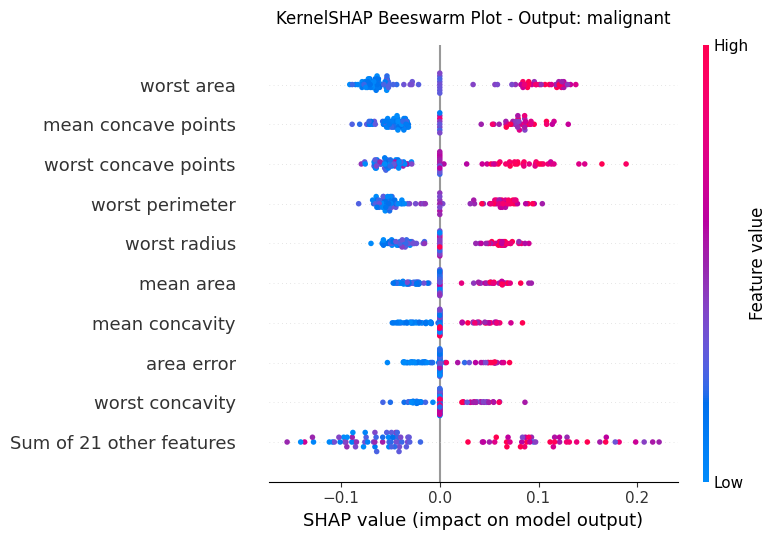

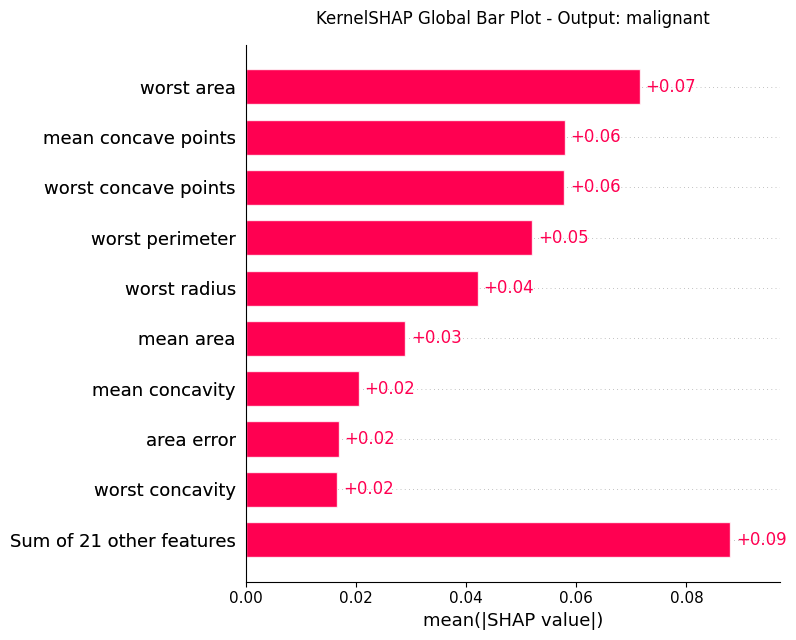

<Figure size 640x480 with 0 Axes>

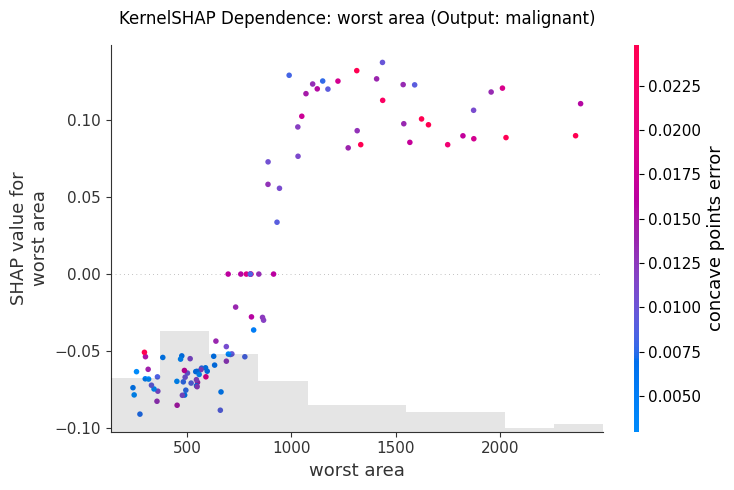


================= KernelSHAP Global - Output: benign =================

--------------- Global KernelSHAP - Raw Values: ---------------
{'method': 'KernelSHAP_Global', 'output_label': 'benign', 'feature_importance': [{'feature': 'worst area', 'mean_abs_shap': 0.07150894522142978}, {'feature': 'mean concave points', 'mean_abs_shap': 0.057875300680980096}, {'feature': 'worst concave points', 'mean_abs_shap': 0.05781438857960509}, {'feature': 'worst perimeter', 'mean_abs_shap': 0.052035735191193956}, {'feature': 'worst radius', 'mean_abs_shap': 0.042090593577492126}, {'feature': 'mean area', 'mean_abs_shap': 0.02897415214394923}, {'feature': 'mean concavity', 'mean_abs_shap': 0.02051273128547139}, {'feature': 'area error', 'mean_abs_shap': 0.016954167769809764}, {'feature': 'worst concavity', 'mean_abs_shap': 0.01661293784309752}, {'feature': 'mean radius', 'mean_abs_shap': 0.01488854712807234}, {'feature': 'worst texture', 'mean_abs_shap': 0.014497022766919599}, {'feature': 'mean perime

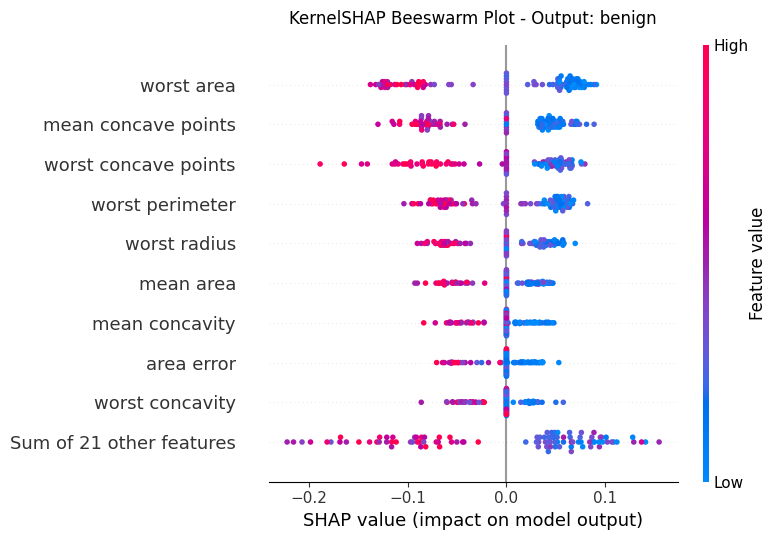

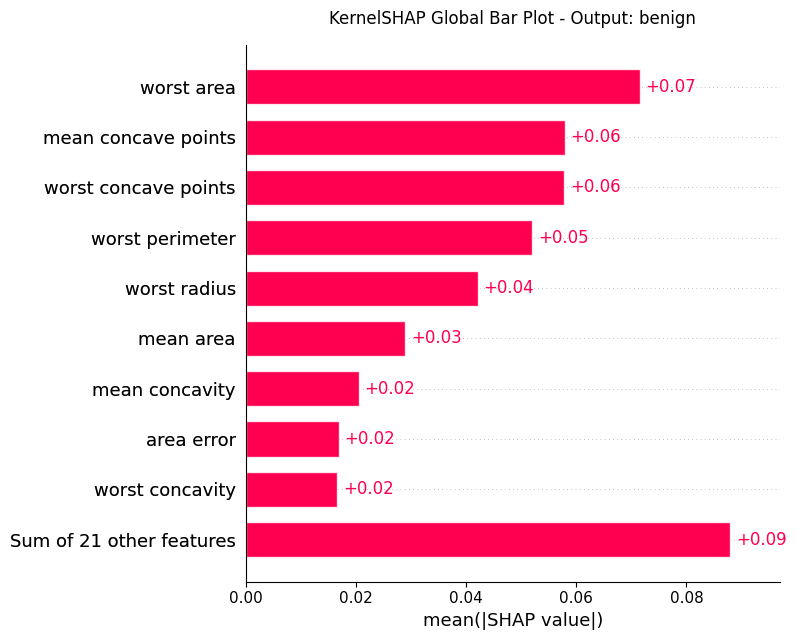

<Figure size 640x480 with 0 Axes>

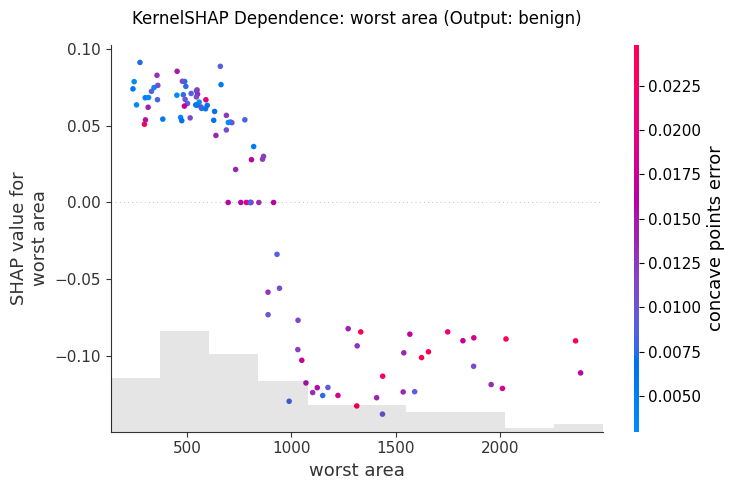

In [41]:
if unified_payload["scope"] in ["global", "both"]:

    # 1. Background Summary (Reference baseline for perturbation)
    background_data = shap.sample(df_ref, 50)

    # 2. Evaluation Sample (KernelSHAP is too slow for entire dataset)
    n_eval_samples = min(100, len(df_ref))
    df_eval = shap.sample(df_ref, n_eval_samples)

    # 3. Select prediction function dynamically
    predict_fn = model.predict_proba if task_type == "classification" else model.predict

    # 4. Initialize KernelExplainer
    kernel_explainer = shap.KernelExplainer(
        lambda x: predict_fn(pd.DataFrame(x, columns=feature_names)),
        background_data
    )

    # Compute raw SHAP values across evaluation instances
    raw_shap_values = kernel_explainer.shap_values(
        pd.DataFrame(df_eval, columns=feature_names),
        nsamples=100
    )

    # 5. Pack raw values into a native shap.Explanation object
    expected_val = kernel_explainer.expected_value

    if isinstance(raw_shap_values, list):
        # Multi-class output: stack to shape (n_samples, n_features, n_classes)
        stacked_values = np.stack(raw_shap_values, axis=-1)
        expected_val = np.array(expected_val)
    else:
        # Single-target regression or binary array
        stacked_values = np.array(raw_shap_values)

    kernel_shap_values_global = shap.Explanation(
        values=stacked_values,
        base_values=expected_val,
        data=df_eval.values if hasattr(df_eval, "values") else df_eval,
        feature_names=feature_names
    )
    print(f"Global KernelSHAP values shape: {kernel_shap_values_global.values.shape}")

    # Resolve dynamic output labels (classes for classification, targets for regression)
    if task_type == "classification":
        output_labels = unified_payload["metadata"].get("class_names")
        if output_labels is None:
            n_classes = kernel_shap_values_global.values.shape[-1] if len(kernel_shap_values_global.values.shape) == 3 else 2
            output_labels = [f"Class_{i}" for i in range(n_classes)]
    else:
        output_labels = targets if isinstance(targets, list) else [targets]

    # Container to collect global SHAP feature importances for downstream LLM
    kshap_global_llm_payload = {}

    # Iterate over resolved output labels
    for out_idx, current_label in enumerate(output_labels):

        print(f"\n================= KernelSHAP Global - Output: {current_label} =================")

        # Slice Explanation object safely for current output
        if len(kernel_shap_values_global.values.shape) == 3:
            # 3D Array: (n_samples, n_features, n_classes/targets) -> Slice to 2D
            exp_global = kernel_shap_values_global[:, :, out_idx]
        else:
            # 2D Array: Single-target regression
            exp_global = kernel_shap_values_global

        # ------------------------- KernelSHAP Raw Values Extraction -------------------------
        mean_abs_shap = np.mean(np.abs(exp_global.values), axis=0)
        global_contributions = [
            {"feature": feat, "mean_abs_shap": float(val)}
            for feat, val in zip(feature_names, mean_abs_shap)
        ]
        global_contributions.sort(key=lambda x: x["mean_abs_shap"], reverse=True)

        kshap_global_llm_payload[str(current_label)] = {
            "method": "KernelSHAP_Global",
            "output_label": str(current_label),
            "feature_importance": global_contributions
        }

        print("\n--------------- Global KernelSHAP - Raw Values: ---------------")
        print(kshap_global_llm_payload[str(current_label)])

        # ------------------------- KernelSHAP Global Output Plots -------------------------
        print(f"\n--------------- Global KernelSHAP - Plots ({current_label}): ---------------")

        # 1. Beeswarm / Summary Plot
        plt.figure()
        shap.plots.beeswarm(exp_global, show=False)
        plt.title(f"KernelSHAP Beeswarm Plot - Output: {current_label}", pad=15)
        plt.tight_layout()
        plt.show()

        # 2. Global Feature Importance Bar Plot
        plt.figure()
        shap.plots.bar(exp_global, show=False)
        plt.title(f"KernelSHAP Global Bar Plot - Output: {current_label}", pad=15)
        plt.tight_layout()
        plt.show()

        # 3. Dynamic Dependence Plot (Top Feature)
        top_feature = global_contributions[0]["feature"]
        plt.figure()
        shap.plots.scatter(
            exp_global[:, top_feature],   # Strictly 1D slice
            color=exp_global,             # 2D slice for auto interaction detection
            show=False
        )
        plt.title(f"KernelSHAP Dependence: {top_feature} (Output: {current_label})", pad=15)
        plt.tight_layout()
        plt.show()

# PFI

In [10]:

user_metric = unified_payload["metadata"].get("scoring_metric")

if user_metric is not None:
    active_scoring = user_metric
else:
    # Automate fallback depending on the task
    active_scoring = "accuracy" if unified_payload["metadata"]["task_type"] == "classification" else "r2"

In [34]:
shap.plots.force?